# Reasoning and Decision Making under Uncertainty
## Group 9: Exercise 6.1

### Clair Weir, Pratyay Mondal


Comparing the prediction abilities of TD(0) and constant-α MC applied to a Markov reward process.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

In [2]:
from helpers import generate_episode

episode, last_state = generate_episode()

print(episode)
print(last_state)

[(C, 0), (B, 0), (A, 0), (B, 0), (A, 0)]
LEFT_TERM


In [3]:
from helpers import MonteCarlo

mc = MonteCarlo()

mc.set_gamma(0.9)

# add MC values after 0 episodes
values = [mc.get_state_values()]

# add MC values after 1 episode
mc.run_episodes(1)
values.append(mc.get_state_values())

# add MC values after 10 episode
mc.run_episodes(9)
values.append(mc.get_state_values())

# add MC values after 100 episode
mc.run_episodes(90)
values.append(mc.get_state_values())


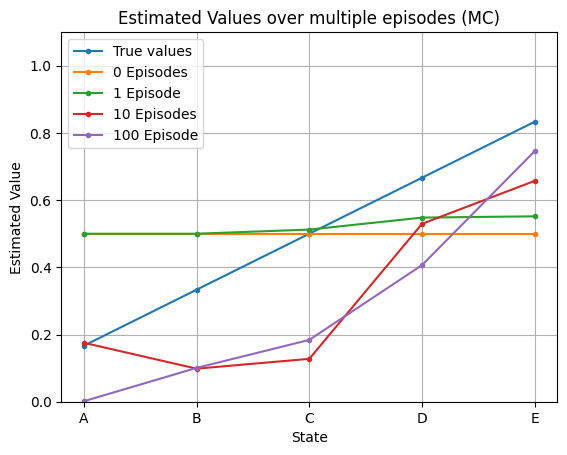

In [4]:
plt.figure()
# plot true values
plt.plot((1/6, 2/6, 3/6, 4/6, 5/6), marker='o', linestyle= '-', markersize=3, label="True values")
val = values[0]
states = [s.name for s in val.keys()]
plt.plot(states, values[0].values(), marker='o', linestyle='-', markersize=3, label="0 Episodes")
plt.plot(states, values[1].values(), marker='o', linestyle='-', markersize=3, label="1 Episode")
plt.plot(states, values[2].values(), marker='o', linestyle='-', markersize=3, label="10 Episodes")
plt.plot(states, values[3].values(), marker='o', linestyle='-', markersize=3, label="100 Episode")
plt.xlabel('State')
plt.ylabel('Estimated Value')
plt.title('Estimated Values over multiple episodes (MC)')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

In [5]:
from helpers import OneStepTemporalDifference

td = OneStepTemporalDifference()

values = [td.get_state_values()]

# add TD values after 1 episode
td.run_episodes(1)
values.append(td.get_state_values())

# add TD values after 10 episode
td.run_episodes(9)
values.append(td.get_state_values())

# add TD values after 100 episode
td.run_episodes(90)
values.append(td.get_state_values())

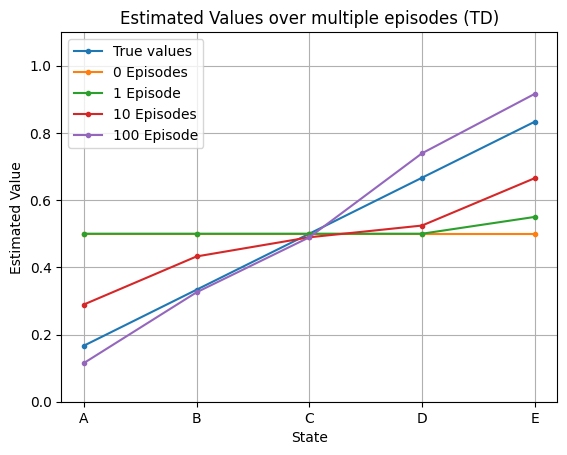

In [6]:
plt.figure()
# plot true values
plt.plot((1/6, 2/6, 3/6, 4/6, 5/6), marker='o', linestyle= '-', markersize=3, label="True values")
val = values[0]
states = [s.name for s in val.keys()]
plt.plot(states, values[0].values(), marker='o', linestyle='-', markersize=3, label="0 Episodes")
plt.plot(states, values[1].values(), marker='o', linestyle='-', markersize=3, label="1 Episode")
plt.plot(states, values[2].values(), marker='o', linestyle='-', markersize=3, label="10 Episodes")
plt.plot(states, values[3].values(), marker='o', linestyle='-', markersize=3, label="100 Episode")
plt.xlabel('State')
plt.ylabel('Estimated Value')
plt.title('Estimated Values over multiple episodes (TD)')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

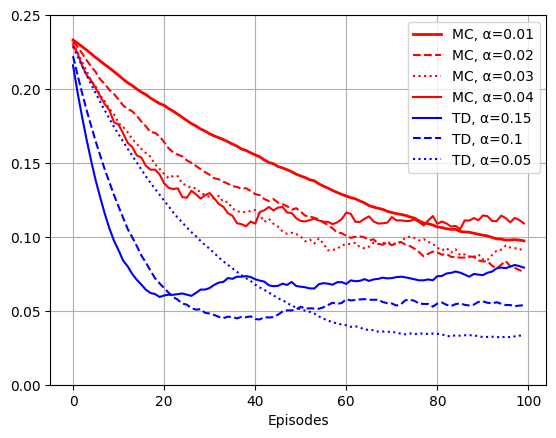

In [14]:
from helpers import get_rms_over_episodes
mc = MonteCarlo()
td = OneStepTemporalDifference()

runs = 100
episodes = 100

plt.figure()

# plot Monte Carlo
mc.set_alpha(0.01)
x, y = get_rms_over_episodes(mc, episodes, runs)
plt.plot(x, y, label="MC, α=0.01", linewidth=2, color='r')

mc.set_alpha(0.02)
x, y = get_rms_over_episodes(mc, episodes, runs)
plt.plot(x, y, label="MC, α=0.02", linestyle='--', color='r')

mc.set_alpha(0.03)
x, y = get_rms_over_episodes(mc, episodes, runs)
plt.plot(x, y, label="MC, α=0.03", linestyle='dotted', color='r')

mc.set_alpha(0.04)
x, y = get_rms_over_episodes(mc, episodes, runs)
plt.plot(x, y, label="MC, α=0.04", color='r')

# plot Temporal Difference
td.set_alpha(0.15)
x, y = get_rms_over_episodes(td, episodes, runs)
plt.plot(x, y, label="TD, α=0.15", color='b')

td.set_alpha(0.1)
x, y = get_rms_over_episodes(td, episodes, runs)
plt.plot(x, y, label="TD, α=0.1", linestyle='--', color='b')

td.set_alpha(0.05)
x, y = get_rms_over_episodes(td, episodes, runs)
plt.plot(x, y, label="TD, α=0.05", linestyle='dotted', color='b')


plt.xlabel('Episodes')
plt.ylim(0, 0.25)
plt.grid(True)
plt.legend()
plt.show()